In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
file_path = r'data/KAG_energydata_complete.csv'
df = pd.read_csv(file_path)

In [20]:
df.head(), df.describe()

(                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
 0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
 1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
 2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
 3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
 4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   
 
       T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
 0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
 1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
 2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
 3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
 4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   
 
    RH_out  Windsp

In [44]:
df.index

Index(['2016-01-11 17:00:00', '2016-01-11 17:10:00', '2016-01-11 17:20:00',
       '2016-01-11 17:30:00', '2016-01-11 17:40:00', '2016-01-11 17:50:00',
       '2016-01-11 18:00:00', '2016-01-11 18:10:00', '2016-01-11 18:20:00',
       '2016-01-11 18:30:00',
       ...
       '2016-05-27 16:30:00', '2016-05-27 16:40:00', '2016-05-27 16:50:00',
       '2016-05-27 17:00:00', '2016-05-27 17:10:00', '2016-05-27 17:20:00',
       '2016-05-27 17:30:00', '2016-05-27 17:40:00', '2016-05-27 17:50:00',
       '2016-05-27 18:00:00'],
      dtype='object', name='date', length=19735)

In [30]:
df.isna().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [26]:
df = df.ffill()

In [46]:
df.index = pd.to_datetime(df.index, errors="coerce")

In [52]:
df.index

DatetimeIndex(['2016-01-11 17:00:00', '2016-01-11 17:10:00',
               '2016-01-11 17:20:00', '2016-01-11 17:30:00',
               '2016-01-11 17:40:00', '2016-01-11 17:50:00',
               '2016-01-11 18:00:00', '2016-01-11 18:10:00',
               '2016-01-11 18:20:00', '2016-01-11 18:30:00',
               ...
               '2016-05-27 16:30:00', '2016-05-27 16:40:00',
               '2016-05-27 16:50:00', '2016-05-27 17:00:00',
               '2016-05-27 17:10:00', '2016-05-27 17:20:00',
               '2016-05-27 17:30:00', '2016-05-27 17:40:00',
               '2016-05-27 17:50:00', '2016-05-27 18:00:00'],
              dtype='datetime64[ns]', name='date', length=19735, freq=None)

In [50]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["is__weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [54]:
df["T1_lag1"] = df["T1"].shift(1)
df["T_out_lag1"] = df["T_out"].shift(1)

In [56]:
df = df.dropna()

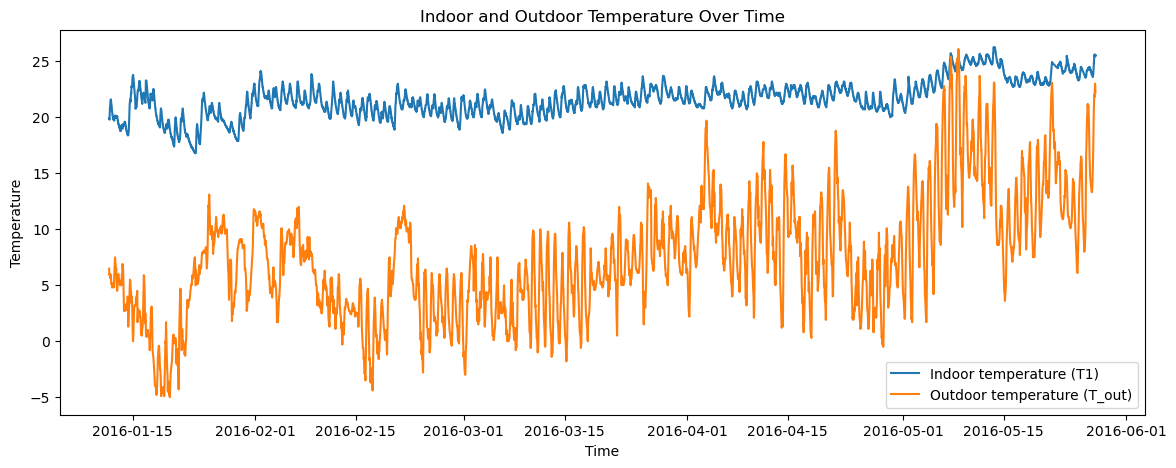

In [58]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["T1"], label="Indoor temperature (T1)")
plt.plot(df.index, df["T_out"], label="Outdoor temperature (T_out)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Indoor and Outdoor Temperature Over Time")
plt.legend()
plt.show()

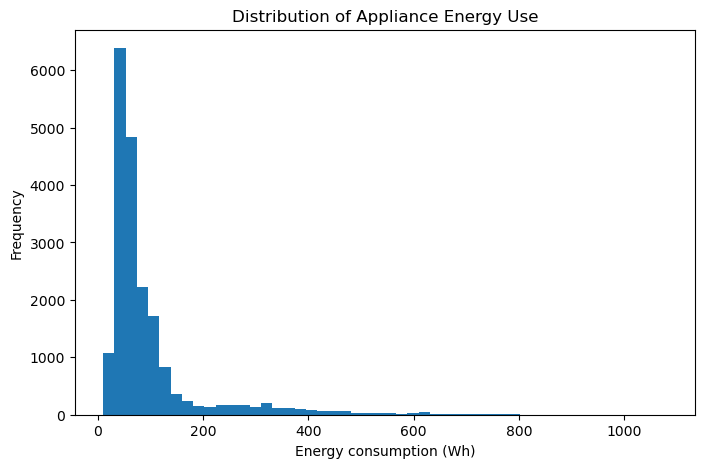

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(df["Appliances"], bins=50)
plt.xlabel("Energy consumption (Wh)")
plt.ylabel("Frequency")
plt.title("Distribution of Appliance Energy Use")
plt.show()

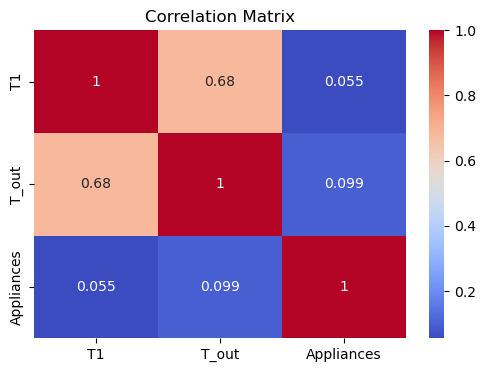

In [62]:
corr_cols = ["T1", "T_out", "Appliances"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()